# FAST Training Runs — Data Condition Experiments

7 training configurations using our evaluation method (shuffled 5-fold KFold + official test set):

| Run | Train Data | Description |
|-----|-----------|-------------|
| 1 | Original (A) | Raw train+val+test from BCIC2020Track3 |
| 2 | Condition B | ICA-cleaned, ALL delta-dominant ICs removed |
| 3 | Condition C | ICA-cleaned, only artifact delta ICs removed |
| 4 | A + B | Original + no-delta combined |
| 5 | A + C | Original + no-artifacts combined |
| 6 | A + B + C | All three conditions combined |
| 7 | B + C | Both ICA conditions combined |

In [1]:
import os
import sys
import h5py
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import logging

torch.set_num_threads(8)
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import KFold
from transformers import PretrainedConfig
import lightning as pl
from lightning.pytorch.callbacks import ModelCheckpoint

logging.getLogger('pytorch_lightning').setLevel(logging.WARNING)
logging.getLogger('lightning').setLevel(logging.WARNING)

# Project imports
sys.path.insert(0, os.path.abspath('..'))
from fast.models import FAST
from fast.data import BasicDataset, Electrodes, Zones, SUBJECTS, CLASSES
from fast.train import EEG_Encoder_Module, inference_on_loader, HistoryCallback
from fast.utils import seed_all

print(f'Subjects: {SUBJECTS}')
print(f'Classes: {CLASSES}')
print(f'Electrodes: {len(Electrodes)} channels')

/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Subjects: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15']
Classes: ['hello', 'help-me', 'stop', 'thank-you', 'yes']
Electrodes: 64 channels


## 1. Configuration

In [2]:
# ============================================================
# Global configuration
# ============================================================
GPU_ID = 0
SEED = 42
MAX_EPOCHS = 200
BATCH_SIZE = 64
N_FOLDS = 5
NUM_WORKERS = 4
PRECISION = 'bf16-mixed'

# Data paths
H5_ORIGINAL = '../Processed/BCIC2020Track3.h5'
H5_COND_B   = '../Processed/BCIC2020Track3_ICA_no_delta.h5'
H5_COND_C   = '../Processed/BCIC2020Track3_ICA_no_artifacts.h5'
H5_TEST     = '../Processed/BCIC2020Track3_Test.h5'

# Base output directory
RESULTS_BASE = '../results/condition_experiments'

# FAST model config
SFREQ = 250
MODEL_CONFIG = PretrainedConfig(
    electrodes=Electrodes,
    zone_dict=Zones,
    dim_cnn=32,
    dim_token=32,
    seq_len=800,
    window_len=SFREQ,
    slide_step=SFREQ // 2,
    head='Conv4Layers',
    n_classes=5,
    num_layers=4,
    num_heads=8,
    dropout=0.1,
)

seed_all(SEED)

## 2. Data Loading Utilities

In [3]:
def load_h5_subject(h5_path, sid):
    """Load X, Y for a single subject from an H5 file."""
    with h5py.File(h5_path, 'r') as f:
        X = f[sid]['X'][()].astype(np.float32)
        Y = f[sid]['Y'][()].astype(np.uint8)
    return X, Y


def load_test_h5(h5_path):
    """Load test data for all subjects from the test H5 file."""
    test_data = {}
    with h5py.File(h5_path, 'r') as f:
        for sid in f.keys():
            X = f[sid]['X'][()].astype(np.float32)
            Y = f[sid]['Y'][()].astype(np.uint8)
            test_data[sid] = (X, Y)
    return test_data


def load_combined_subject(h5_paths, sid):
    """Load and concatenate data for one subject from multiple H5 files."""
    X_parts, Y_parts = [], []
    for path in h5_paths:
        X, Y = load_h5_subject(path, sid)
        X_parts.append(X)
        Y_parts.append(Y)
    return np.concatenate(X_parts, axis=0), np.concatenate(Y_parts, axis=0)


# Verify all files exist
for name, path in [('Original', H5_ORIGINAL), ('Cond B', H5_COND_B), 
                    ('Cond C', H5_COND_C), ('Test', H5_TEST)]:
    assert os.path.exists(path), f'{name} not found: {path}'
    print(f'{name}: {path} OK')

# Load test data once (shared across all runs)
test_per_subject = load_test_h5(H5_TEST)
print(f'\nTest set loaded: {len(test_per_subject)} subjects, '
      f'{test_per_subject["01"][0].shape[0]} trials each')

Original: ../Processed/BCIC2020Track3.h5 OK
Cond B: ../Processed/BCIC2020Track3_ICA_no_delta.h5 OK
Cond C: ../Processed/BCIC2020Track3_ICA_no_artifacts.h5 OK
Test: ../Processed/BCIC2020Track3_Test.h5 OK

Test set loaded: 15 subjects, 50 trials each


## 3. Define the 7 Experiment Configurations

In [4]:
EXPERIMENTS = {
    'run1_original': {
        'name': 'Run 1: Original Data (A)',
        'h5_paths': [H5_ORIGINAL],
        'output_dir': os.path.join(RESULTS_BASE, 'run1_original'),
    },
    'run2_condB': {
        'name': 'Run 2: Condition B (No Delta)',
        'h5_paths': [H5_COND_B],
        'output_dir': os.path.join(RESULTS_BASE, 'run2_condB'),
    },
    'run3_condC': {
        'name': 'Run 3: Condition C (No Artifacts)',
        'h5_paths': [H5_COND_C],
        'output_dir': os.path.join(RESULTS_BASE, 'run3_condC'),
    },
    'run4_A_B': {
        'name': 'Run 4: Original + Condition B',
        'h5_paths': [H5_ORIGINAL, H5_COND_B],
        'output_dir': os.path.join(RESULTS_BASE, 'run4_A_B'),
    },
    'run5_A_C': {
        'name': 'Run 5: Original + Condition C',
        'h5_paths': [H5_ORIGINAL, H5_COND_C],
        'output_dir': os.path.join(RESULTS_BASE, 'run5_A_C'),
    },
    'run6_A_B_C': {
        'name': 'Run 6: Original + Cond B + Cond C',
        'h5_paths': [H5_ORIGINAL, H5_COND_B, H5_COND_C],
        'output_dir': os.path.join(RESULTS_BASE, 'run6_A_B_C'),
    },
    'run7_B_C': {
        'name': 'Run 7: Condition B + Condition C',
        'h5_paths': [H5_COND_B, H5_COND_C],
        'output_dir': os.path.join(RESULTS_BASE, 'run7_B_C'),
    },
}

# Preview data sizes per experiment
print(f'{"Experiment":<35} {"Trials/Subject":<18} {"Total Trials"}')
print('-' * 70)
for key, exp in EXPERIMENTS.items():
    n_h5 = len(exp['h5_paths'])
    trials_per_subj = 350 * n_h5
    total = trials_per_subj * 15
    print(f'{exp["name"]:<35} {trials_per_subj:<18} {total}')

Experiment                          Trials/Subject     Total Trials
----------------------------------------------------------------------
Run 1: Original Data (A)            350                5250
Run 2: Condition B (No Delta)       350                5250
Run 3: Condition C (No Artifacts)   350                5250
Run 4: Original + Condition B       700                10500
Run 5: Original + Condition C       700                10500
Run 6: Original + Cond B + Cond C   1050               15750
Run 7: Condition B + Condition C    700                10500


## 4. Training Function

Per-subject 5-fold CV with:
- Shuffled KFold (seed=42)
- Mini-batch training (batch_size=64)
- Best model selection on val_acc
- Official test set evaluation
- Learning curves + checkpoints saved per fold

In [5]:
def train_experiment(experiment_config, model_config, test_per_subject):
    """
    Run a full training experiment: per-subject 5-fold CV with test evaluation.
    
    Parameters
    ----------
    experiment_config : dict
        Must contain 'name', 'h5_paths', 'output_dir'.
    model_config : PretrainedConfig
        FAST model configuration.
    test_per_subject : dict
        {SID: (X_test, Y_test)} for official test evaluation.
    
    Returns
    -------
    pd.DataFrame
        Per-subject results with Best_Val_Acc, Test_Acc, Test_F1.
    """
    exp_name = experiment_config['name']
    h5_paths = experiment_config['h5_paths']
    save_dir = experiment_config['output_dir']
    os.makedirs(save_dir, exist_ok=True)
    
    print(f'\n{"=" * 70}')
    print(f'  {exp_name}')
    print(f'  Data sources: {[os.path.basename(p) for p in h5_paths]}')
    print(f'  Output: {save_dir}')
    print(f'{"=" * 70}')
    
    subject_results = []
    global_pred = []
    global_true = []
    
    for SID in SUBJECTS:
        print(f'\n--- SUBJECT {SID} ---')
        
        # Load data (single or combined)
        if len(h5_paths) == 1:
            X_sub, Y_sub = load_h5_subject(h5_paths[0], SID)
        else:
            X_sub, Y_sub = load_combined_subject(h5_paths, SID)
        
        print(f'  Data: {X_sub.shape}, labels: {np.unique(Y_sub, return_counts=True)}')
        
        kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
        fold_metrics = []
        best_fold_acc = -np.inf
        best_fold_ckpt = None
        best_train_len = 1
        
        for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_sub)):
            x_train, y_train = X_sub[train_idx], Y_sub[train_idx]
            x_val, y_val = X_sub[val_idx], Y_sub[val_idx]
            
            train_loader = DataLoader(
                BasicDataset(x_train, y_train), batch_size=BATCH_SIZE,
                shuffle=True, num_workers=NUM_WORKERS, pin_memory=True
            )
            val_loader = DataLoader(
                BasicDataset(x_val, y_val), batch_size=BATCH_SIZE,
                shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
            )
            
            model = EEG_Encoder_Module(model_config, MAX_EPOCHS, len(train_loader))
            history_cb = HistoryCallback()
            
            fold_dir = os.path.join(save_dir, f'sub-{SID}')
            os.makedirs(fold_dir, exist_ok=True)
            ckpt_cb = ModelCheckpoint(
                dirpath=fold_dir,
                filename=f'fold-{fold_idx}-best',
                monitor='val_acc',
                mode='max',
                save_top_k=1,
                verbose=False,
            )
            
            trainer = pl.Trainer(
                strategy='auto',
                accelerator='gpu',
                devices=[GPU_ID],
                max_epochs=MAX_EPOCHS,
                callbacks=[history_cb, ckpt_cb],
                enable_progress_bar=True,
                enable_checkpointing=True,
                precision=PRECISION,
                logger=False,
                num_sanity_val_steps=0,
            )
            
            trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
            
            fold_best = float(ckpt_cb.best_model_score) if ckpt_cb.best_model_score is not None else float('nan')
            fold_metrics.append([fold_idx, fold_best])
            
            # Save learning curves
            if all(len(v) > 0 for v in history_cb.history.values()):
                min_len = min(len(v) for v in history_cb.history.values())
                clean_history = {k: v[:min_len] for k, v in history_cb.history.items()}
                pd.DataFrame(clean_history).to_csv(
                    os.path.join(fold_dir, f'fold-{fold_idx}_history.csv'), index_label='Epoch'
                )
                
                # Plot learning curves
                fig, axes = plt.subplots(1, 2, figsize=(10, 4))
                
                axes[0].plot(clean_history.get('loss', []), label='Train Loss', color='blue')
                axes[0].plot(clean_history.get('val_loss', []), label='Val Loss', color='orange', linestyle='--')
                axes[0].set_title(f'Subject {SID} Fold {fold_idx+1} Loss')
                axes[0].set_xlabel('Epoch')
                axes[0].set_ylabel('Loss')
                axes[0].legend()
                axes[0].grid(True, alpha=0.3)
                
                axes[1].plot(clean_history.get('acc', []), label='Train Acc', color='green')
                axes[1].plot(clean_history.get('val_acc', []), label='Val Acc', color='red', linestyle='--')
                axes[1].set_title(f'Subject {SID} Fold {fold_idx+1} Accuracy')
                axes[1].set_xlabel('Epoch')
                axes[1].set_ylabel('Accuracy')
                axes[1].legend()
                axes[1].grid(True, alpha=0.3)
                
                plt.tight_layout()
                plt.savefig(os.path.join(fold_dir, f'fold-{fold_idx}_curves.png'), dpi=100)
                plt.close()
            
            print(f'  Fold {fold_idx+1}: best val_acc={fold_best:.4f}')
            
            if ckpt_cb.best_model_path and fold_best > best_fold_acc:
                best_fold_acc = fold_best
                best_fold_ckpt = ckpt_cb.best_model_path
                best_train_len = len(train_loader)
        
        # Save fold metrics
        df_folds = pd.DataFrame(fold_metrics, columns=['Fold', 'Best_Val_Acc'])
        df_folds.to_csv(os.path.join(save_dir, f'sub-{SID}', 'fold_metrics.csv'), index=False)
        
        # Load best fold model and evaluate on test set
        test_acc = np.nan
        test_f1 = np.nan
        
        if best_fold_ckpt:
            best_model = EEG_Encoder_Module.load_from_checkpoint(
                best_fold_ckpt,
                config=model_config,
                max_epochs=MAX_EPOCHS,
                niter_per_ep=best_train_len,
                weights_only=False,
            )
            subj_best_path = os.path.join(save_dir, f'sub-{SID}', 'best_subject.pth')
            torch.save(best_model.model.state_dict(), subj_best_path)
            
            # Official test set evaluation
            if SID in test_per_subject:
                X_test, Y_test = test_per_subject[SID]
                test_loader = DataLoader(
                    BasicDataset(X_test, Y_test), batch_size=BATCH_SIZE,
                    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
                )
                y_pred, y_true = inference_on_loader(best_model.model, test_loader)
                test_acc = accuracy_score(y_true, y_pred)
                test_f1 = f1_score(y_true, y_pred, average='macro')
                np.savetxt(
                    os.path.join(save_dir, f'sub-{SID}', 'test_predictions.csv'),
                    np.array([y_pred, y_true]).T, delimiter=',', fmt='%d',
                    header='Predicted,True'
                )
                global_pred.append(y_pred)
                global_true.append(y_true)
            
            print(f'  Best val_acc={best_fold_acc:.4f} | Test Acc={test_acc:.4f}, F1={test_f1:.4f}')
        else:
            print(f'  WARNING: No checkpoint saved for subject {SID}')
        
        subject_results.append([SID, best_fold_acc, test_acc, test_f1])
    
    # Save summary
    df_subjects = pd.DataFrame(
        subject_results, columns=['Subject', 'Best_Val_Acc', 'Test_Acc', 'Test_F1']
    )
    df_subjects.to_csv(os.path.join(save_dir, 'summary_per_subject.csv'), index=False)
    
    # Save global predictions
    if global_pred and global_true:
        gp = np.concatenate(global_pred)
        gt = np.concatenate(global_true)
        np.savetxt(
            os.path.join(save_dir, 'global_test_predictions.csv'),
            np.array([gp, gt]).T, delimiter=',', fmt='%d', header='Predicted,True'
        )
    
    # Plot per-subject accuracy
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(df_subjects['Subject'], df_subjects['Test_Acc'],
                  color='skyblue', edgecolor='black')
    mean_acc = df_subjects['Test_Acc'].mean()
    ax.axhline(y=mean_acc, color='red', linestyle='--', linewidth=2,
               label=f'Mean: {mean_acc:.4f}')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h, f'{h:.2f}',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{exp_name} — Test Accuracy per Subject', fontsize=14)
    ax.set_xlabel('Subject ID')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, min(1.0, max(df_subjects['Test_Acc'].max(), mean_acc) * 1.15))
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'global_subject_accuracy.png'), dpi=150)
    plt.show()
    plt.close()
    
    print(f'\n{exp_name} COMPLETE')
    print(f'Mean Test Acc: {mean_acc:.4f} +/- {df_subjects["Test_Acc"].std():.4f}')
    print(f'Summary saved to {save_dir}/summary_per_subject.csv')
    
    return df_subjects

## 5. Run 1: Original Data (A)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores



  Run 1: Original Data (A)
  Data sources: ['BCIC2020Track3.h5']
  Output: ../results/condition_experiments/run1_original

--- SUBJECT 01 ---
  Data: (350, 64, 800), labels: (array([0, 1, 2, 3, 4], dtype=uint8), array([70, 70, 70, 70, 70]))


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/kay/miniconda3/envs/fast_shap/lib/python3.10/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ FAST               │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 98                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

  Fold 4: best val_acc=0.6286


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ FAST               │  191 K │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ train_f1  │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 5 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 191 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 191 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 98                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=200` reached.


  Fold 5: best val_acc=0.6571
  Best val_acc=0.7429 | Test Acc=0.6800, F1=0.6765


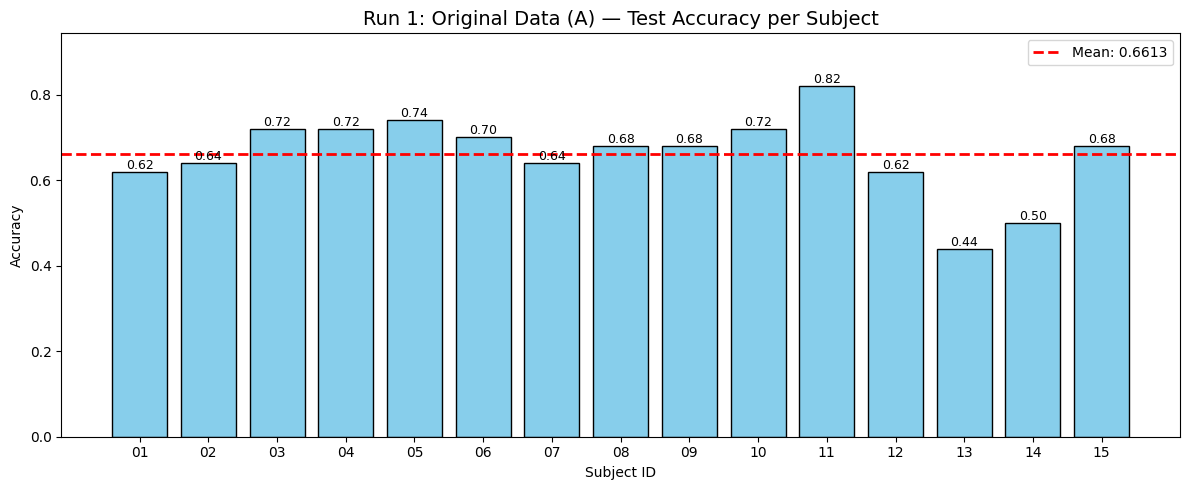


Run 1: Original Data (A) COMPLETE
Mean Test Acc: 0.6613 +/- 0.0940
Summary saved to ../results/condition_experiments/run1_original/summary_per_subject.csv


In [6]:
df_run1 = train_experiment(EXPERIMENTS['run1_original'], MODEL_CONFIG, test_per_subject)

## 6. Run 2: Condition B (No Delta)

In [ ]:
df_run2 = train_experiment(EXPERIMENTS['run2_condB'], MODEL_CONFIG, test_per_subject)

## 7. Run 3: Condition C (No Artifacts)

In [ ]:
df_run3 = train_experiment(EXPERIMENTS['run3_condC'], MODEL_CONFIG, test_per_subject)

## 8. Run 4: Original + Condition B

In [ ]:
df_run4 = train_experiment(EXPERIMENTS['run4_A_B'], MODEL_CONFIG, test_per_subject)

## 9. Run 5: Original + Condition C

In [ ]:
df_run5 = train_experiment(EXPERIMENTS['run5_A_C'], MODEL_CONFIG, test_per_subject)

## 10. Run 6: Original + Condition B + Condition C

In [ ]:
df_run6 = train_experiment(EXPERIMENTS['run6_A_B_C'], MODEL_CONFIG, test_per_subject)

## 11. Run 7: Condition B + Condition C

In [ ]:
df_run7 = train_experiment(EXPERIMENTS['run7_B_C'], MODEL_CONFIG, test_per_subject)

## 12. Comparison Summary

In [ ]:
# Collect all results
all_results = {}
for key, exp in EXPERIMENTS.items():
    csv_path = os.path.join(exp['output_dir'], 'summary_per_subject.csv')
    if os.path.exists(csv_path):
        all_results[key] = pd.read_csv(csv_path)

# Build comparison table
comparison = []
for key, df in all_results.items():
    exp = EXPERIMENTS[key]
    comparison.append({
        'Experiment': exp['name'],
        'Trials/Subject': 350 * len(exp['h5_paths']),
        'Mean_Val_Acc': df['Best_Val_Acc'].mean(),
        'Std_Val_Acc': df['Best_Val_Acc'].std(),
        'Mean_Test_Acc': df['Test_Acc'].mean(),
        'Std_Test_Acc': df['Test_Acc'].std(),
        'Mean_Test_F1': df['Test_F1'].mean(),
    })

df_comparison = pd.DataFrame(comparison)
print(df_comparison.to_string(index=False, float_format='%.4f'))

# Save comparison
df_comparison.to_csv(os.path.join(RESULTS_BASE, 'comparison_summary.csv'), index=False)

In [ ]:
# Grouped bar chart: Test accuracy per subject across all experiments
fig, ax = plt.subplots(figsize=(16, 6))

n_experiments = len(all_results)
x = np.arange(len(SUBJECTS))
width = 0.8 / n_experiments
colors = plt.cm.Set2(np.linspace(0, 1, n_experiments))

for i, (key, df) in enumerate(all_results.items()):
    exp = EXPERIMENTS[key]
    offsets = x + (i - n_experiments / 2 + 0.5) * width
    ax.bar(offsets, df['Test_Acc'], width, label=exp['name'], color=colors[i],
           edgecolor='black', linewidth=0.5)

ax.set_xlabel('Subject ID', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Test Accuracy per Subject — All Conditions', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(SUBJECTS)
ax.legend(fontsize=8, loc='upper right')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_BASE, 'comparison_per_subject.png'), dpi=150)
plt.show()

In [ ]:
# Mean accuracy comparison bar chart
fig, ax = plt.subplots(figsize=(12, 5))

names = [r['Experiment'] for r in comparison]
means = [r['Mean_Test_Acc'] for r in comparison]
stds = [r['Std_Test_Acc'] for r in comparison]

bars = ax.bar(range(len(names)), means, yerr=stds, capsize=5,
              color=colors[:len(names)], edgecolor='black')

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.replace('Run ', 'R') for n in names], rotation=30, ha='right')
ax.set_ylabel('Mean Test Accuracy')
ax.set_title('Mean Test Accuracy Across Conditions (mean +/- std)', fontsize=14)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_BASE, 'comparison_mean_accuracy.png'), dpi=150)
plt.show()